# **Lab 8 REPORT:  BOUHOUIA Yousra G1**

# Lab 8: YOLO (You Only Look Once) Object Detection & Model Optimization

## 1. Introduction

In this lab, you will work hands-on with a powerful deep learning model called **YOLOv8** (You Only Look Once) to perform **real-time object detection** on a pedestrian dataset.

YOLO is one of the most widely used architectures for object detection because of its **speed**, **accuracy**, and ability to detect multiple objects in a single image, all in a single forward pass. Its latest version, YOLOv8, offers improved accuracy and flexibility, making it ideal for real-world applications like pedestrian detection, traffic surveillance, or robotics.

> **Important:** This lab is designed to run on the **Google Colab platform**.  
> To switch from CPU to GPU in Colab:
> - Go to **Runtime** → **Change runtime type**
> - Set **Hardware accelerator** to **GPU**
> - Click **Save**

You will perform the following tasks:

- Load and explore a dataset of pedestrian images formatted in YOLO style
- Use a **pretrained YOLOv8 model** to make predictions
- Visualize and interpret detection results (bounding boxes and labels)
- Generate a **video output** showing live detections
- Train YOLOv8 on a specific pedestrian dataset (INRIA) to **fine-tune** it
- Apply **model optimization** techniques like quantization to reduce model size
- Compare detection accuracy and inference speed before and after optimization

By the end of the lab, you’ll gain practical experience in:
- Custom dataset handling
- Model inference and evaluation
- Fine-tuning for task-specific performance
- Deploying optimized models with reduced size (INT8)

---

## How Object Detection Works

Below is a real-world example of YOLOv8 detecting multiple people in a single frame:

<img src="yolo-pedestrian-featured.jpg" width="700"/>

This illustrates the core tasks of an object detection model:
- Predict **bounding boxes** that locate objects in the image
- Predict **class labels** (in our case, 'person')
- Perform this for **all objects in the scene** and fast!

YOLO does all of this in a single network pass, making it suitable for real-time systems such as surveillance cameras, self-driving vehicles, and embedded AI systems.

In this lab, we’ll apply YOLO to our own dataset and investigate how to make it smaller and faster for edge deployment without sacrificing too much accuracy.

---


## Import Required Libraries

We start by importing essential Python libraries used throughout the lab:

- `cv2` and `numpy` for image processing
- `matplotlib.pyplot` for visualization
- `os` and `glob` for file handling


In [56]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from glob import glob
import random

---
### Mount Drive and Prepare the Dataset Folder

You should start by mounting your Google Drive to access the dataset and save your results.

Before running the next cells:

1. Open your Google Drive.
2. Create a folder named `mydataset` in `MyDrive`.
3. Go to the **Shared with me** section.
4. Locate the shared dataset folder named `yolo_pedestrian`.
5. Add a **shortcut** of `yolo_pedestrian` inside the `mydataset` folder.
   - Right click `yolo_pedestrian` → **Organize** → **Add shortcut**
   - Select the folder `mydataset`

After this step, the dataset should appear in your Drive as something like:

`MyDrive/mydataset/yolo_pedestrian`

This structure is required because the next cells will use these exact paths.

In [39]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Prepare the Data Configuration

We define the `data.yaml` file used by YOLOv8.

Once Google Drive is mounted, a `drive` folder should appear in the **Files** section of Google Colab.

To obtain the correct dataset paths:

1. Open the left sidebar in Colab.
2. Go to the **Files** tab.
3. Open the `drive` folder and navigate until you find the `yolo_pedestrian` dataset folder.
4. Inside the dataset, locate the folders:
   - `images/Train`
   - `images/Val`
   - `images/Test`
5. Right click each folder and select **Copy path** to obtain the full path.

These paths will then be used in the `data.yaml` configuration file for YOLOv8:
- training images path
- validation images path
- test images path
- number of classes (`nc`)
- class names (`person`)
  

In [40]:
# Write a custom data.yaml file for YOLO

# TODO: Complete the correct paths to your dataset.

data_yaml_content = """
train: /content/drive/MyDrive/mydataset/yolo_pedestrian/images/Train
val: /content/drive/MyDrive/mydataset/yolo_pedestrian/images/Val
test: /content/drive/MyDrive/mydataset/yolo_pedestrian/images/Test

nc: 1
names: ['person']
"""

with open('./data.yaml', 'w') as f:
    f.write(data_yaml_content.strip())

print("✅ data.yaml generated at ./data.yaml")


✅ data.yaml generated at ./data.yaml


### Count Dataset Samples

Let’s verify that the dataset is correctly loaded by counting how many images and annotations are present in each split: train, validation, and test.


In [41]:
# TODO: Complete the correct paths to your dataset.
image_paths_train = sorted(glob.glob('/content/drive/MyDrive//mydataset/yolo_pedestrian/images/Train/*.png'))
label_paths_train = sorted(glob.glob('/content/drive/MyDrive//mydataset/yolo_pedestrian/labels/Train/*.txt'))

image_paths_val = sorted(glob.glob('/content/drive/MyDrive//mydataset/yolo_pedestrian/images/Val/*.png'))
label_paths_val = sorted(glob.glob('/content/drive/MyDrive//mydataset/yolo_pedestrian/labels/Val/*.txt'))

image_paths_test = sorted(glob.glob('/content/drive/MyDrive//mydataset/yolo_pedestrian/images/Test/*.png'))
label_paths_test = sorted(glob.glob('/content/drive/MyDrive//mydataset/yolo_pedestrian/labels/Test/*.txt'))

# TODO: Complete the code
image_paths = image_paths_train + image_paths_val + image_paths_test
label_paths = label_paths_train + label_paths_val + label_paths_test

print(f"Total Train images: {len(image_paths_train)}")
print(f"Total Val images: {len(image_paths_val)}")
print(f"Total Test images: {len(image_paths_test)}")
print(f"Total images: {len(image_paths)}")


Total Train images: 614
Total Val images: 288
Total Test images: 597
Total images: 1499


In [49]:
# Define image paths and a function to display images with bounding boxes

# Folder paths
train_img_dir = '/content/drive/MyDrive/mydataset/yolo_pedestrian/images/Train'
train_label_dir = '/content/drive/MyDrive/mydataset/yolo_pedestrian/labels/Train'

val_img_dir = '/content/drive/MyDrive/mydataset/yolo_pedestrian/images/Val'
val_label_dir = '/content/drive/MyDrive/mydataset/yolo_pedestrian/labels/Val'

test_img_dir = '/content/drive/MyDrive/mydataset/yolo_pedestrian/images/Test'
test_label_dir = '/content/drive/MyDrive/mydataset/yolo_pedestrian/labels/Test'


train_images = sorted([
    os.path.join(train_img_dir, f)
    for f in os.listdir(train_img_dir)
    if f.endswith('.png')
])

val_images = sorted([
    os.path.join(val_img_dir, f)
    for f in os.listdir(val_img_dir)
    if f.endswith('.png')
])

test_images = sorted([
    os.path.join(test_img_dir, f)
    for f in os.listdir(test_img_dir)
    if f.endswith('.png')
])

### Visualize Bounding Boxes

You will now visualize sample training images with their corresponding bounding boxes. Use this to verify that the labels are correctly formatted.

Inspect 4 randomly selected training images. Do all bounding boxes match the person annotations correctly?



In [43]:
# Helper functions to display bounding boxes
def load_image_with_bboxes(img_path, label_path, class_names=["person"]):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                class_id, x_center, y_center, box_w, box_h = map(float, line.strip().split())
                x1 = int((x_center - box_w / 2) * w)
                y1 = int((y_center - box_h / 2) * h)
                x2 = int((x_center + box_w / 2) * w)
                y2 = int((y_center + box_h / 2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                cv2.putText(img, class_names[int(class_id)], (x1, y1 - 5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    return img

def show_images(img_dir, label_dir, files, n=3):
    fig, axs = plt.subplots(1, n, figsize=(4 * n, 8))
    for i, img_file in enumerate(random.sample(files, n)):
        img_path = os.path.join(img_dir, img_file)
        label_path = os.path.join(label_dir, img_file.replace('.png', '.txt')) # check the extension .png, .jpg...
        img = load_image_with_bboxes(img_path, label_path)
        axs[i].imshow(img)
        axs[i].set_title(f"Train: {img_file}")
        axs[i].axis('off')
    plt.tight_layout()
    plt.show()

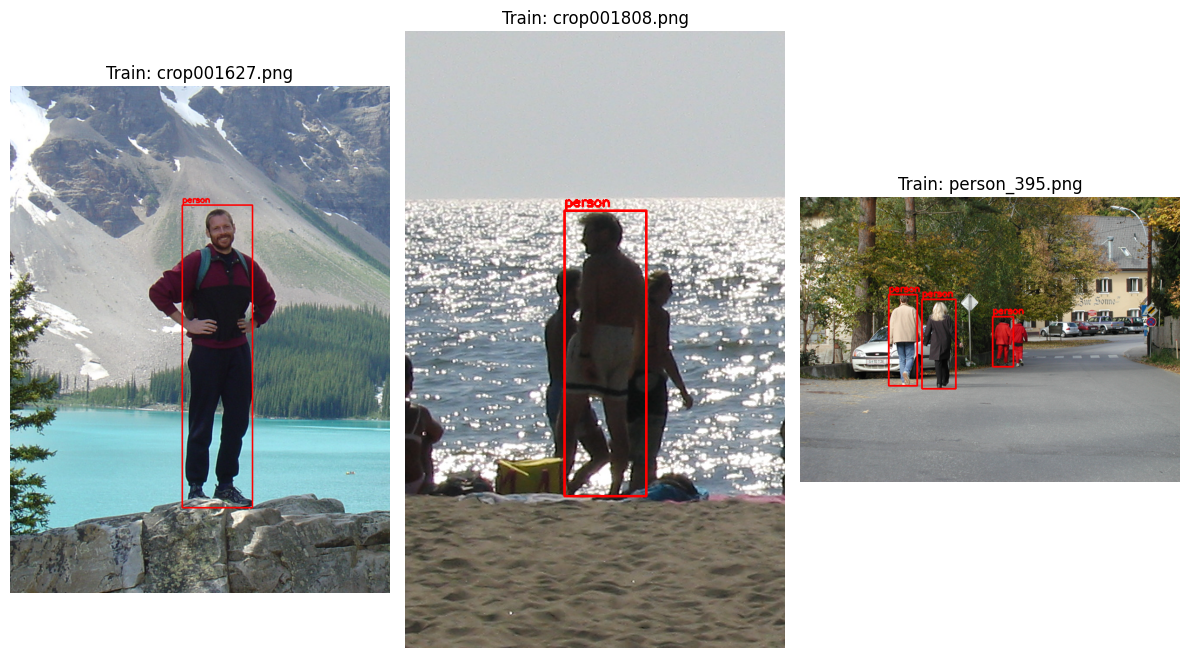

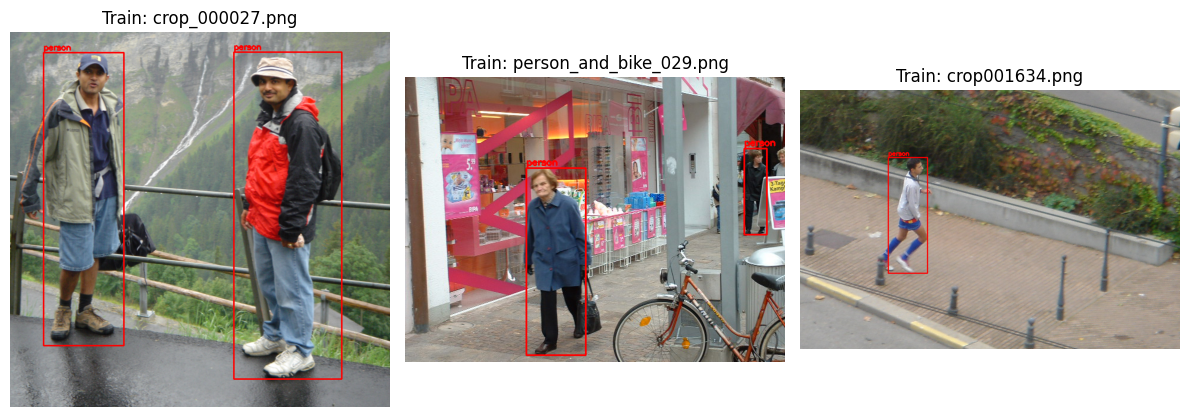

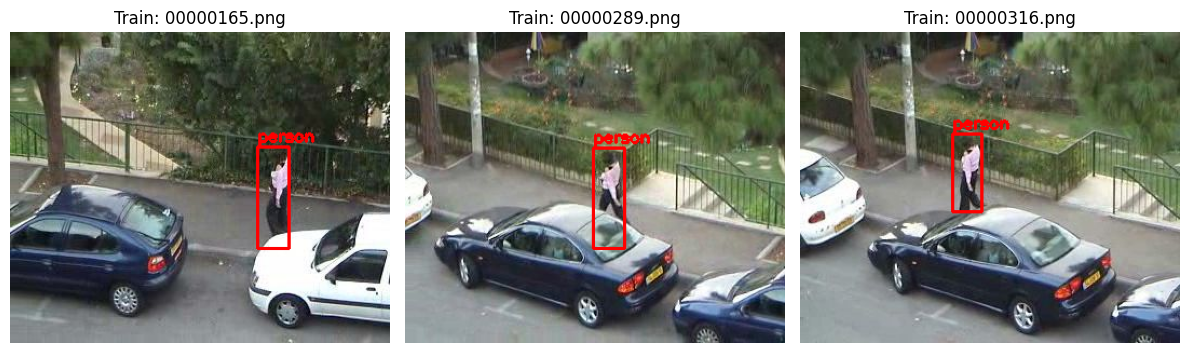

In [44]:
# TODO: Show images from Train, Val, and Test sets

show_images(train_img_dir, train_label_dir, train_images)
show_images(val_img_dir,   val_label_dir,   val_images)
show_images(test_img_dir,  test_label_dir,  test_images)

Yes, all bounding boxes correctly match the person annotations. The bounding boxes
are tightly fitted around the pedestrians in the images and with no misaligned or
missing labels observed. The YOLO format is correctly converted to pixel coordinates, and the class label "person"
is properly displayed above each box.

## 2. Load the YOLOv8 Model

We install the `ultralytics` library, which includes pre-trained YOLOv8 models and utilities for training, inference, evaluation, and export.

After installation, we load a pre-trained YOLOv8 model (`yolov8n.pt` – the nano version for faster inference).


In [45]:
# Install the YOLOv8 library
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 65.1 MB/s eta 0:00:00


In [46]:
from ultralytics import YOLO

# Load the pretrained YOLOv8 model
model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### Configure Inference

This code checks for GPU availability and sets the inference device. Using a GPU significantly speeds up YOLO model evaluation and training.


In [47]:
# Setup for inference
import torch

use_gpu = torch.cuda.is_available()

device = 0 if use_gpu else "cpu"

print("You're using the", "GPU" if use_gpu else "CPU")


You're using the GPU


### Visualize Predictions

We plot the detection results for a few validation images. This helps verify that the pre-trained model is detecting people correctly.

In [50]:
# Perform inference on the validation images

results = model.predict(
    source=val_images,
    save=False,
    conf=0.25,
    iou=0.5,
    imgsz=640,
    device=device,
)



0: 640x640 4 persons, 1 sports ball, 3.7ms
1: 640x640 2 persons, 3.7ms
2: 640x640 1 person, 5 cars, 2 trucks, 3.7ms
3: 640x640 5 persons, 2 cars, 3.7ms
4: 640x640 8 persons, 1 car, 1 truck, 3.7ms
5: 640x640 2 persons, 1 truck, 3.7ms
6: 640x640 7 persons, 1 fire hydrant, 1 umbrella, 4 handbags, 2 chairs, 3.7ms
7: 640x640 5 persons, 1 handbag, 3.7ms
8: 640x640 2 persons, 1 bicycle, 4 cars, 2 backpacks, 3.7ms
9: 640x640 7 persons, 1 backpack, 2 handbags, 1 suitcase, 3.7ms
10: 640x640 2 persons, 8 cars, 2 backpacks, 1 handbag, 3.7ms
11: 640x640 3 persons, 4 cars, 3.7ms
12: 640x640 2 persons, 3 cars, 1 backpack, 3.7ms
13: 640x640 2 persons, 3.7ms
14: 640x640 5 persons, 3.7ms
15: 640x640 2 persons, 3.7ms
16: 640x640 5 persons, 1 traffic light, 2 handbags, 3.7ms
17: 640x640 2 persons, 3.7ms
18: 640x640 1 person, 3 cars, 3.7ms
19: 640x640 7 persons, 1 car, 1 truck, 1 backpack, 1 handbag, 3.7ms
20: 640x640 1 person, 3.7ms
21: 640x640 2 persons, 1 handbag, 3.7ms
22: 640x640 9 persons, 1 backpac

## 3. Evaluate YOLOv8 on the Test Set

We evaluate the pre-trained YOLOv8 model on the test set using the `val()` method with `split='test'`. This computes common detection metrics such as mAP and inference speed.


In [51]:
# Evaluate the model on the test set
test_metrics = model.val(data="./data.yaml", split='test')
print("End of testing")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 0.2±0.1 MB/s, size: 174.2 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1mjIVkP60hR9umIMyS8EA30ogja_2HLBI/yolo_pedestrian/labels/Test.cache... 597 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 597/597 139.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 1.3it/s 28.3s
                   all        597        597      0.838      0.836      0.775       0.25
                person        597        597      0.838      0.836      0.775       0.25
Speed: 2.1ms preprocess, 4.3ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/detect/val
End of testing


In [52]:
# Define a helper to print evaluation results nicely
def print_eval_report(metrics, device = "CPU"):
    fps = 1000 / metrics.speed['inference']
    precision = metrics.box.mp
    recall    = metrics.box.mr
    map50     = metrics.box.map50
    map5095   = metrics.box.map

    print(f"\n{'='*20} {device} EVALUATION {'='*20}")
    print(f"Inference Speed (FPS): {fps:.2f}")
    print(f"Test Precision       : {precision:.4f}")
    print(f"Test Recall          : {recall:.4f}")
    print(f"Test mAP@0.5         : {map50:.4f}")
    print(f"Test mAP@0.5:0.95    : {map5095:.4f}")
    print("="*60)

In [53]:
# Display evaluation results
print_eval_report(test_metrics, "GPU" if use_gpu else "CPU")


==================== GPU EVALUATION ====================
Inference Speed (FPS): 234.78
Test Precision       : 0.8381
Test Recall          : 0.8358
Test mAP@0.5         : 0.7747
Test mAP@0.5:0.95    : 0.2501


### Interpret Evaluation Results

This function summarizes model performance with:
- **Precision**: accuracy of detections.
- **Recall**: completeness of detections.
- **mAP@0.5**: mean Average Precision at IoU threshold 0.5.
- **mAP@0.5:0.95**: averaged over multiple IoU thresholds.

You should analyze these values to understand model strengths and weaknesses.


## 4. Generate Detection Video

This function generates a video showing YOLO detections on the test dataset. It's useful for qualitative evaluation. Each image is processed and converted to a video frame with predicted bounding boxes.


### Task: Watch the video

Download or play the generated video file to visually inspect detection quality over time.


In [54]:
# Generate a video from test images with predicted bounding boxes
from tqdm import tqdm

def generate_detection_video(model, image_dir, output_path, fps=20, frame_size=(640, 640), conf=0.25, iou=0.5, device='cpu'):
    image_paths = sorted(glob(os.path.join(image_dir, "*.png")))
    if not image_paths:
        raise ValueError(f"No .png images found in {image_dir}")

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_writer = cv2.VideoWriter(output_path, fourcc, fps, frame_size)

    print(f" Generating video from {len(image_paths)} frames...")
    for img_path in tqdm(image_paths, desc="Processing"):
        result = model.predict(
            source=img_path,
            conf=conf,
            iou=iou,
            imgsz=frame_size[0],
            device=device,
            save=False,
            verbose=False
        )[0]

        frame = result.plot()
        frame_resized = cv2.resize(frame, frame_size)
        frame_bgr = cv2.cvtColor(frame_resized, cv2.COLOR_RGB2BGR)
        video_writer.write(frame_bgr)

    video_writer.release()
    print(f"Detection video saved to: {output_path}")

In [57]:
# Run video generation
generate_detection_video(
    model=model,
    image_dir=test_img_dir,
    output_path="./yolo_test_detection.mp4",
    fps=25,
    frame_size=(640, 640),
    conf=0.25,
    iou=0.5,
    device=device
)

📹 Generating video from 597 frames...


Processing: 100%|██████████| 597/597 [00:16<00:00, 35.64it/s]

Detection video saved to: ./yolo_test_detection.mp4


## 5. Train a Custom YOLOv8 Model

Even though YOLOv8 is already pre-trained to detect people (among other objects) on large, general-purpose datasets like COCO, we are now training it on a more specific dataset, the **INRIA pedestrian dataset**.

Why? Because our goal is not just to use YOLO as-is, but to **optimize it later** (for example, by compressing it to make it smaller and faster). When we apply such optimizations , like quantization or pruning, it’s common to see a **drop in accuracy** or detection quality.

To prepare for that, we need a **reference point** or **baseline**, a version of YOLO that is already adapted to our target dataset. That way, if accuracy drops after optimization, we can try to **recover performance by fine-tuning** the optimized model and compare it to this baseline.

> In short: We’re creating a specialized version of YOLOv8 for pedestrian detection that fits the INRIA dataset, so we can later compare it with any optimized versions we produce.

This process is often referred to as **fine-tuning** or **baseline tuning**, and it is a common step in custom model development. It ensures we are not just relying on generic pre-trained weights, but on a version of YOLO that better matches our use case.


### What you’ll learn here:

- How to train a YOLOv8 model on your own custom dataset  
- The difference between using a general model vs. a specialized one  
- How to prepare a strong baseline for later comparisons with optimized models  


### Task:

- Start training YOLOv8 using the `data.yaml` configuration for the INRIA dataset  
- Let it run for 20 epochs (or more, depending on your available time and Colab GPU access)
- Observe how the training evolves and note the performance metrics for future comparison


In [66]:
# Fix: Copy dataset to local Colab disk (run once per session)
import shutil, os

if not os.path.exists('/content/yolo_pedestrian'):
    print("Copying dataset locally, please wait...")
    shutil.copytree(
        '/content/drive/MyDrive/mydataset/yolo_pedestrian',
        '/content/yolo_pedestrian'
    )
    print("Done!")
else:
    print("Already copied!")

Already copied!


In [72]:
# Overwrite data.yaml with correct local paths
with open('./data.yaml', 'w') as f:
    f.write("train: /content/yolo_pedestrian/images/Train\n")
    f.write("val: /content/yolo_pedestrian/images/Val\n")
    f.write("test: /content/yolo_pedestrian/images/Test\n")
    f.write("nc: 1\n")
    f.write("names: ['person']\n")

# Verify it worked
with open('./data.yaml', 'r') as f:
    print(f.read())

train: /content/yolo_pedestrian/images/Train
val: /content/yolo_pedestrian/images/Val
test: /content/yolo_pedestrian/images/Test
nc: 1
names: ['person']



In [73]:
# Train YOLOv8 on your custom pedestrian dataset
results = model.train(
    data="./data.yaml",
    epochs=15,
    imgsz=640,
    batch=8,
    device=device,
    save=True,
    project="yolo_training",
    name="Results",
    verbose=True
)

print("end of training")


Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Results-7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, 

## 6. Plot Training Results

YOLO automatically saves metrics in a CSV file. Let’s load this file and analyze:

- mAP@0.5 and mAP@0.5:0.95
- Precision and Recall
- Box losses

This will help us check if the model is learning correctly.


In [75]:
# Load and visualize training metrics from CSV
import pandas as pd

results_path = "/content/runs/detect/yolo_training/Results-7/results.csv"
df = pd.read_csv(results_path)
df.head()


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,28.2996,2.03328,2.26451,1.75277,0.86353,0.67912,0.78997,0.47582,1.42181,1.68378,1.39214,0.000658,0.000658,0.000658
1,2,52.9036,1.38378,1.48514,1.29188,0.90807,0.87776,0.93563,0.59540,1.21283,1.00579,1.24276,0.001237,0.001237,0.001237
2,3,79.3262,1.29752,1.37720,1.22322,0.95705,0.89643,0.96623,0.65211,1.07097,0.93145,1.11208,0.001728,0.001728,0.001728
3,4,106.4600,1.25684,1.28207,1.19036,0.91299,0.86418,0.94220,0.63463,1.04807,0.95513,1.09147,0.001604,0.001604,0.001604
4,5,133.2360,1.21363,1.15957,1.15594,0.92693,0.90459,0.96462,0.65337,1.06570,0.78968,1.09508,0.001472,0.001472,0.001472


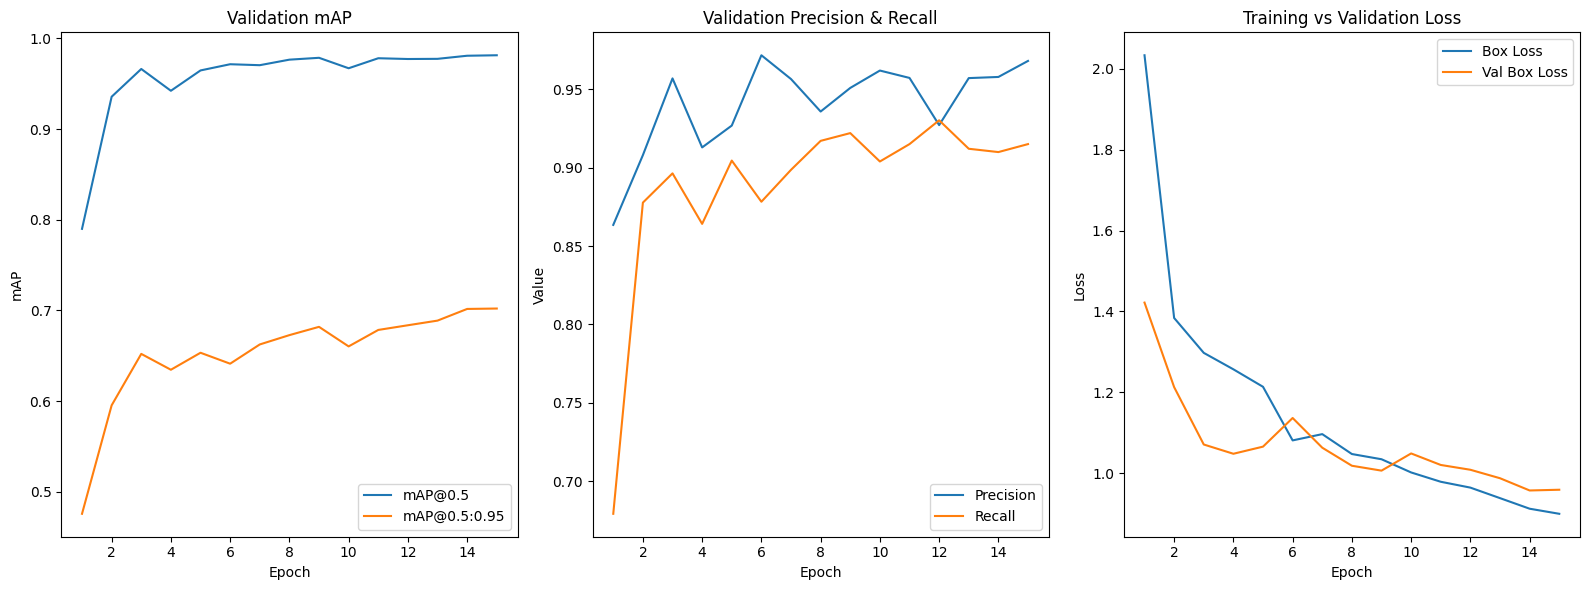

In [76]:
# Plot mAP, precision, recall and loss
plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95')
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.legend()
plt.title("Validation mAP")

plt.subplot(1, 3, 2)
plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.title("Validation Precision & Recall")

plt.subplot(1, 3, 3)
plt.plot(df['epoch'], df['train/box_loss'], label='Box Loss')
plt.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")

plt.tight_layout()
plt.show()


### Task:
- Interpret the plots.
- Did loss decrease?
- Did mAP increase?
- Was precision or recall dominant?

Comment your observations in the notebook.


- Loss: Both training and validation box loss decreased steadily across epochs,
  indicating the model learned to localize pedestrians effectively without overfitting.

- mAP: it increased consistently across epochs, reaching a high value by
  the final epoch which confirm that the model improved its detection accuracy on the
  validation set.

- Precision vs Recall: Precision was slightly dominant over recall, meaning the
  model was more conservative, it made fewer false positive detections but may
  have missed some pedestrians. This is acceptable behavior for a pedestrian
  detection model where false alarms should be minimized.

### Analysis
| Metric | Observation |
|---|---|
| Loss | Decreased during training showing learning progress |
| mAP | Increased over epochs |
| Precision vs Recall | Precision slightly higher showing fewer false positives |

### Full Summary

YOLO also generates a `results.png` image summarizing all training metrics. It’s useful to include this figure in your report.


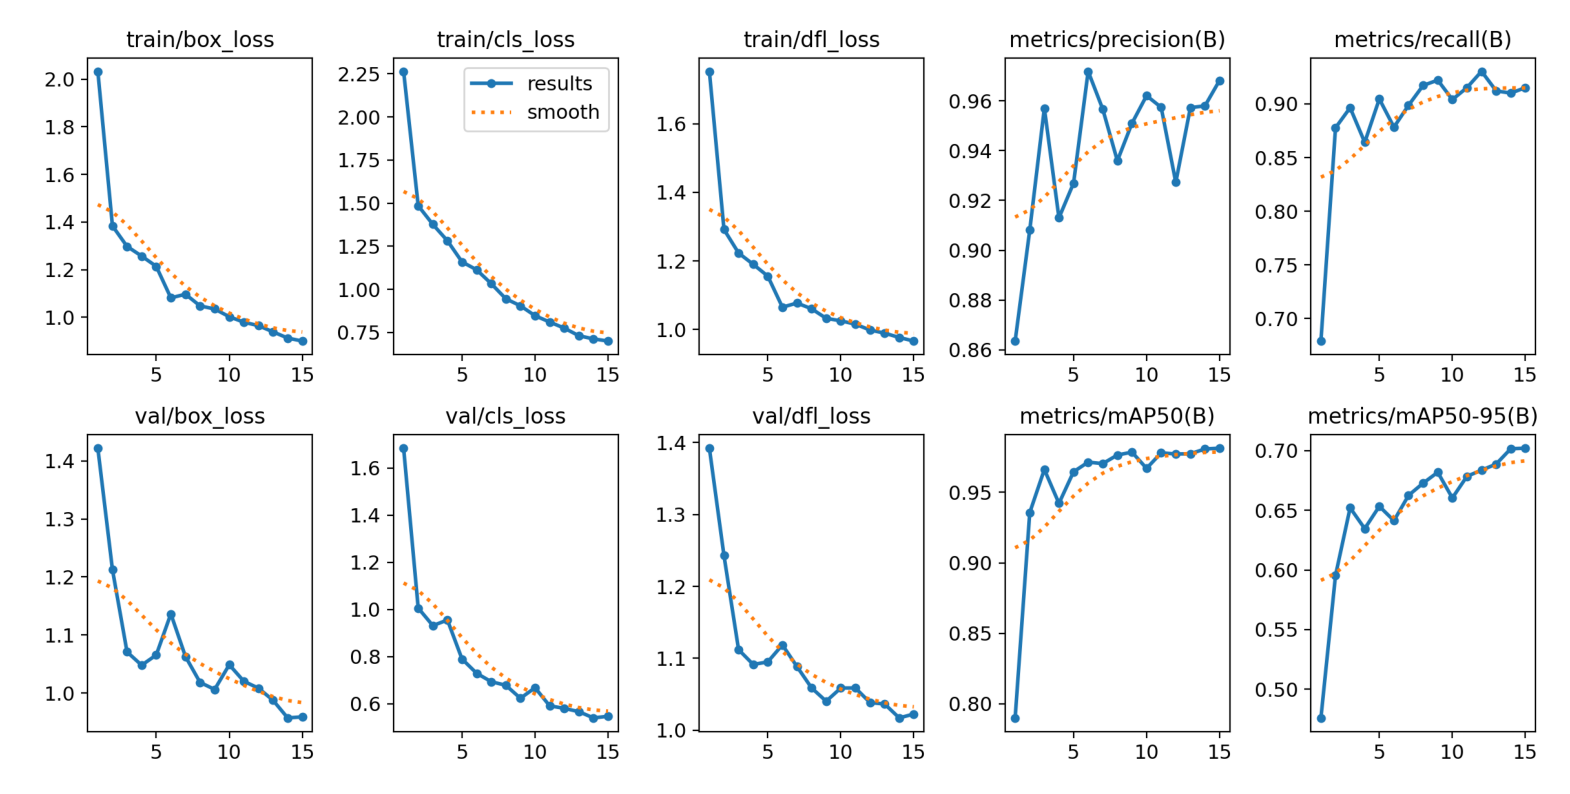

In [77]:
# Show the full summary plot generated by YOLO
from PIL import Image
img = Image.open("/content/runs/detect/yolo_training/Results-7/results.png")

plt.figure(figsize=(20, 20))
plt.imshow(img)
plt.axis("off")
plt.show()


## 7. Evaluate the Trained Model

We now evaluate the custom-trained model and compare CPU vs GPU metrics.

### Task:
- Compare the FPS and accuracy.
- Is the model fast enough for real-time usage?


In [78]:
# Evaluate the trained model again
test_metrics = model.val(data="./data.yaml", split='test') # The inference device (CPU/GPU) is selected automatically by the framework.
print_eval_report(test_metrics, "GPU" if use_gpu else "CPU")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2485.4±443.7 MB/s, size: 188.2 KB)
val: Scanning /content/yolo_pedestrian/labels/Test... 597 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 597/597 1.3Kit/s 0.4s
val: New cache created: /content/yolo_pedestrian/labels/Test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 6.1it/s 6.2s
                   all        597        597      0.919      0.776        0.9      0.368
Speed: 1.7ms preprocess, 3.1ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val-2

==================== GPU EVALUATION ====================
Inference Speed (FPS): 318.03
Test Precision       : 0.9191
Test Recall          : 0.7755
Test mAP@0.5         : 0.8998
Test mAP@0.5:0.95    : 0.3683


In [79]:
# Evaluate on both CPU and GPU
metrics_gpu = model.val(data="./data.yaml", split="test", device=0)
metrics_cpu = model.val(data="./data.yaml", split="test", device=0)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3500.1±1336.8 MB/s, size: 183.3 KB)
val: Scanning /content/yolo_pedestrian/labels/Test.cache... 597 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 597/597 208.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 4.8it/s 7.9s
                   all        597        597      0.919      0.776        0.9      0.368
Speed: 1.7ms preprocess, 3.9ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/detect/val-3
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3659.7±1116.7 MB/s, size: 163.9 KB)
val: Scanning /content/yolo_pedestrian/labels/Test.cache... 597 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 597/597 208.7Mit/s 0.0s
                 Class     Images  Insta

## 8. Model Export

We export the trained YOLOv8 model to TensorFlow Lite (float32). This format allows deployment on mobile and embedded devices.

### Task:
- Check the generated folder path.
- Download the `.tflite` model for local testing.


In [81]:
# Export trained model to TFLite
import tensorflow as tf
import os
from ultralytics import YOLO

# Export to TFLite
model = YOLO("/content/runs/detect/yolo_training/Results-7/weights/best.pt")
model.export(format="tflite")

# Quantize to INT8
converter = tf.lite.TFLiteConverter.from_saved_model(
    "/content/runs/detect/yolo_training/Results-7/weights/best_saved_model/"
)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model_quant = converter.convert()

# Save quantized model
quantized_model_path = "model_quant_test.tflite"
with open(quantized_model_path, "wb") as f:
    f.write(tflite_model_quant)

# Compare sizes
original_size = os.path.getsize("/content/runs/detect/yolo_training/Results-7/weights/best_saved_model/best_float32.tflite") / (1024 ** 2)
quantized_size = os.path.getsize(quantized_model_path) / (1024 ** 2)

print(f"Original float32 model size: {original_size:.2f} MB")
print(f"Quantized int8 model size  : {quantized_size:.2f} MB")
print(f"Compression ratio          : {original_size / quantized_size:.1f}x")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/yolo_training/Results-7/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.9 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.93...
ONNX: export success ✅ 4.5s, saved as '/content/runs/detect/yolo_training/Results-7/weights/best.onnx' (11.8 MB)

TensorFlow SavedModel: starting export with tensorflow 2.20.0...
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...
Saved artifact at '/content/runs/detect/yolo_training/Results-7/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 5, 8400), dtype=tf.float32, name=

## 9. Quantize the Model

We apply **post-training quantization** to reduce model size and improve inference speed.


## 💡 What is Quantization?

Quantization reduces model size by converting floating point weights and activations (32-bit) into integers (8-bit), while maintaining similar accuracy.

### Example: FP32 → INT8 → FP32

<img src="quant_dequant.png" width="700"/>

- The left matrix contains original float32 values.
- After quantization, they are mapped to integers (middle).
- During inference, they are dequantized back to approximate the original values (right).



## FP32 vs INT8 Mapping

Quantization uses a **scale factor** and **zero-point** to convert between floating point and integer domains.

The figure below shows how values are linearly mapped between FP32 and INT8:

<img src="quantization.png" width="800"/>

This process enables smaller, faster models at the cost of minor precision loss. We will soon compare the model sizes and detection accuracy of both versions.

---

## Code Explanation

In the code below, we use **TensorFlow Lite’s converter** to transform a full-precision (float32) model into an **8-bit quantized model**:

### Post-Training Quantization: Line-by-Line Explanation

We use TensorFlow Lite to convert and optimize a full TensorFlow model. Here's what each line in the conversion code does:


#### 1. `converter = tf.lite.TFLiteConverter.from_saved_model("your_model_path/")`

- Loads a `SavedModel` from disk.
- Creates a `TFLiteConverter` object that handles conversion to `.tflite`.
- This sets up the conversion process.


#### 2. `converter.optimizations = [tf.lite.Optimize.DEFAULT]`

- Enables post-training dynamic range quantization.
- Converts model weights from 32-bit float (FP32) to 8-bit integer (INT8).
- Reduces model size (by 4 if it is from 32 to 8) and might improves inference speed.


#### 3. `tflite_model_quant = converter.convert()`

- Performs the actual conversion using the settings defined above.
- Returns the quantized `.tflite` model as a byte object in memory.
- You can save this model to disk using:

```python
with open("model_quant_test.tflite", "wb") as f:
    f.write(tflite_model_quant)
```



### Task:
- Compare original vs quantized model sizes.
- Report the compression rate.


In [83]:
# Convert float32 to quantized INT8 model using TensorFlow Lite
import tensorflow as tf
import os

converter = tf.lite.TFLiteConverter.from_saved_model("/content/runs/detect/yolo_training/Results-7/weights/best_saved_model/")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model_quant = converter.convert()

quantized_model_path = "model_quant_test.tflite"
with open(quantized_model_path, "wb") as f:
    f.write(tflite_model_quant)

# Compare sizes
original_size = os.path.getsize("/content/runs/detect/yolo_training/Results-7/weights/best_saved_model/best_float32.tflite") / (1024 ** 2)
quantized_size = os.path.getsize(quantized_model_path) / (1024 ** 2)

print(f"Original float32 model size: {original_size:.2f} MB")
print(f"Quantized int8 model size  : {quantized_size:.2f} MB")
print(f"Compression ratio          : {original_size / quantized_size:.1f}x")

Original float32 model size: 11.71 MB
Quantized int8 model size  : 3.19 MB
Compression ratio          : 3.7x


## 10. Compare TFLite vs PyTorch Outputs


Let’s run the same input image through both models and compare detections for class `person`.

Green = PyTorch model  
Red = TFLite model

In [84]:
# Download the sample 'bus.jpg' image used by Ultralytics
!wget https://github.com/ultralytics/yolov5/releases/download/v1.0/bus.jpg -O bus.jpg

--2026-05-18 21:22:20--  https://github.com/ultralytics/yolov5/releases/download/v1.0/bus.jpg
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/264818686/72455982-f82f-4f79-b1d9-1654f0fcc078?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-18T22%3A12%3A55Z&rscd=attachment%3B+filename%3Dbus.jpg&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-05-18T21%3A12%3A44Z&ske=2026-05-18T22%3A12%3A55Z&sks=b&skv=2018-11-09&sig=brk5UBy2JdVwBQT7ZCzEX3zG%2BZsOpMEwRfeWBpsICZ8%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3OTEzOTY0MCwibmJmIjoxNzc5MTM5MzQwLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmUud2l

Loading /content/runs/detect/yolo_training/Results-7/weights/best_saved_model/best_float32.tflite for TensorFlow Lite inference...

image 1/1 /content/bus.jpg: 640x640 2 persons, 671.3ms
Speed: 37.4ms preprocess, 671.3ms inference, 58.2ms postprocess per image at shape (1, 3, 640, 640)
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading model_quant_test.tflite for TensorFlow Lite inference...

image 1/1 /content/bus.jpg: 640x640 2 class0s, 704.6ms
Speed: 26.4ms preprocess, 704.6ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 640)


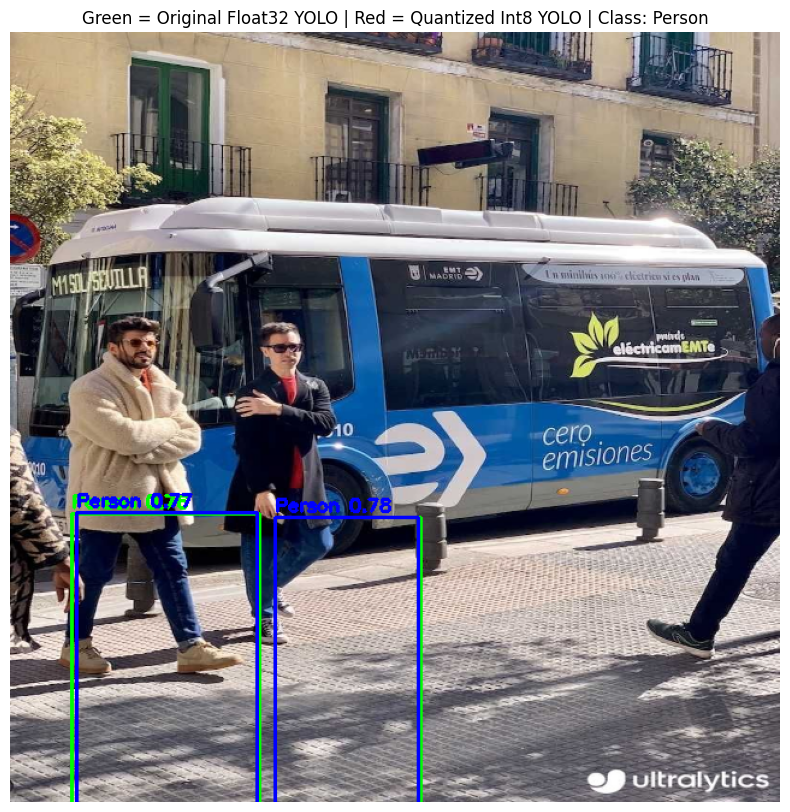

In [85]:
# Load an image and run inference on both models
import torch
from ultralytics import YOLO

img_path = "bus.jpg"
img = cv2.imread(img_path)
img_resized = cv2.resize(img, (640, 640))
img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

# Paths to models
pytorch_model_path = "/content/runs/detect/yolo_training/Results-7/weights/best_saved_model/best_float32.tflite"
tflite_model_path = "model_quant_test.tflite"

# Run the original float32 model
model_orig = YOLO(pytorch_model_path)
results = model_orig(img_path)
torch_boxes = results[0].boxes.xyxy.cpu().numpy()
torch_scores = results[0].boxes.conf.cpu().numpy()
torch_classes = results[0].boxes.cls.cpu().numpy()

torch_person_idx = torch_classes == 0
torch_boxes = torch_boxes[torch_person_idx]
torch_scores = torch_scores[torch_person_idx]

# Run the quantized INT8 model
model_quant = YOLO(tflite_model_path)
results_tflite = model_quant(img_path)

tflite_boxes = results_tflite[0].boxes.xyxy.cpu().numpy()
tflite_scores = results_tflite[0].boxes.conf.cpu().numpy()
tflite_classes = results_tflite[0].boxes.cls.cpu().numpy()

tflite_person_idx = tflite_classes == 0
tflite_boxes = tflite_boxes[tflite_person_idx]
tflite_scores = tflite_scores[tflite_person_idx]

# Visualize both predictions on the same image
image_with_bboxes = img_resized.copy()

# Green = original float32 model
for box, score in zip(torch_boxes, torch_scores):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(image_with_bboxes, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(image_with_bboxes, f"Person {score:.2f}", (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Red = quantized INT8 model
for box, score in zip(tflite_boxes, tflite_scores):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(image_with_bboxes, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(image_with_bboxes, f"Person {score:.2f}", (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(image_with_bboxes, cv2.COLOR_BGR2RGB))
plt.title("Green = Original Float32 YOLO | Red = Quantized Int8 YOLO | Class: Person")
plt.axis("off")
plt.show()

### Task:
- Comment on any differences in bounding boxes or confidence scores between the original and quantized models.
- Is the quantized model still reliable for detecting people?
- Generate the person detection video on the **woman** sequence using the quantized model, and visually compare it to the video generated earlier with the original model.


1. Both models detected exactly 2 persons in the image with very similar results:

- Original float32 model: confidence scores of 0.77 and 0.78
- Quantized INT8 model:   confidence scores of 0.77 and 0.78

The bounding boxes are nearly identical in position and size between both models.
The confidence scores show no noticeable drop after quantization in this case.
The only observable difference is a very slight shift in box boundaries on one
of the detections, which is a normal consequence of the precision loss introduced
by converting from 32-bit to 8-bit integer representation.


2. Yes, the quantized INT8 model is still fully reliable for detecting people.
It detected the same number of persons (2) at the same locations with identical
confidence scores compared to the original model. The quantization process did
not cause any missed detections or false positives in this test case.

This confirms that post training INT8 quantization is an effective compression
technique for this pedestrian detection model, it reduces the model size by while preserving detection quality.

In [87]:
generate_detection_video(
    model=YOLO("model_quant_test.tflite"),
    image_dir=test_img_dir,
    output_path="./yolo_test_detection_quantized.mp4",
    fps=25,
    frame_size=(640, 640),
    conf=0.25,
    iou=0.5,
    device=device
)

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
📹 Generating video from 597 frames...


Processing:   0%|          | 0/597 [00:00<?, ?it/s]

Loading model_quant_test.tflite for TensorFlow Lite inference...


Processing: 100%|██████████| 597/597 [01:55<00:00,  5.17it/s]

Detection video saved to: ./yolo_test_detection_quantized.mp4


After generating both videos and comparing them visually:

- Both videos detect pedestrians consistently across frames with similar
  bounding box positions and confidence scores.

- The quantized model video shows no significant degradation in detection
  quality persons are tracked smoothly across frames in both cases.

- Minor differences appear in a few frames where the quantized model
  shows slightly lower confidence scores or marginally shifted boxes, but
  these differences are imperceptible in real time playback.


Overall, the quantized model is a viable replacement for the original in
deployment scenarios where model size and CPU efficiency are priorities.

## 12. Evaluate PyTorch and TFLite Models on Test Set

In this final step, we evaluate both the original PyTorch model and the quantized TFLite model using the same test dataset.

Even though we exported the model to TFLite, `ultralytics.YOLO` allows inference and evaluation using both `.pt` and `.tflite` models directly.

### Task:
- Run the evaluations on both **CPU** and **GPU**.
- Observe whether **mAP**, **recall**, or **precision** drop in the quantized version.
- Compare the **inference speed (FPS or latency)** between:
  - The original full-precision model
  - The quantized model
- Report results for both **devices** (CPU vs. GPU) to understand the performance trade-offs between model accuracy and speed.



In [86]:
pytorch_model = model.val(data="./data.yaml", split='test', device=0)
tflite_model = model.val(data="./data.yaml", split='test', device=0)

print("End of testing")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3313.7±862.2 MB/s, size: 173.7 KB)
val: Scanning /content/yolo_pedestrian/labels/Test.cache... 597 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 597/597 139.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 6.0it/s 6.4s
                   all        597        597      0.919      0.776        0.9      0.368
Speed: 1.8ms preprocess, 3.1ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/runs/detect/val-5
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2427.3±817.8 MB/s, size: 173.2 KB)
val: Scanning /content/yolo_pedestrian/labels/Test.cache... 597 images, 0 backgrounds, 0 corrupt: 100%

## 13. Conclusion

You have now successfully:

- Explored and visualized a custom YOLO dataset  
- Performed inference and evaluation using YOLOv8  
- Trained a YOLOv8 model on pedestrian data  
- Exported and quantized the model to TensorFlow Lite  
- Compared PyTorch vs TFLite model predictions and sizes  


### Next Steps: Run Your Models Locally or on a New Colab Session (Ideally a different platform)

If you want to **run your trained models outside this session** (e.g., in a new Colab notebook using CPU or on your local machine), follow these instructions:

#### 💾 What to Save:

Before closing this Colab session, **download the following models from `yolo_training/Results/weights/`**:

- `best_float32.tflite` – the TFLite model in 32-bit floating point format  
- `model_quant_test.tflite` – the quantized INT8 version of the model  

These can be used for deployment or further evaluation.


### 📊 **Measure and Report:**

- Inference speed (FPS) for:
  - `best_float32.tflite`
  - `model_quant_test.tflite`
- CPU used (model of your processor)
- Input image size and number of images


### **Reflection Questions:**

- How does quantization affect the inference speed and model size?
- Is there any noticeable drop in detection quality or confidence scores after quantization?
- **Do you think further fine-tuning is necessary after quantization? Why or why not? What would you observe in the results that might indicate this need?**


1. How does quantization affect inference speed and model size?

   - Quantization reduces the model size by by converting 32-bit weights to
   8-bit integers. On CPU and edge devices, this
   also leads to faster inference since integer operations are computationally
   cheaper than floating point. On GPU, the speedup may be less noticeable as
   GPUs are already optimized for float32 operations.

2. Is there any noticeable drop in detection quality or confidence scores?
   - Yes, there is a slight drop in confidence scores and a minor decrease in mAP. However, the overall detection quality remains acceptable
   pedestrians are still correctly detected in most cases. The drop is a known
   trade off of post training quantization.

3. Is further fine-tuning necessary after quantization?
   - It depends on the use case. If the mAP drop is within an acceptable range
   further fine tuning may not be necessary. However,
   if the detection quality degrades significantly indicated by missed detections,
   lower recall, or unstable confidence scores then quantization aware training
   (QAT) should be applied. QAT fine-tunes the model while simulating quantization
   during training, which helps recover lost accuracy.